# Static FY0 report probes and CSI300 RankIC

This notebook is an explicitly conflicting alternative to the strict PIT walk-forward protocol. It uses all valid FY0 report labels in fixed feature-date splits, does not filter on `label_available_date`, opens validation and test in one Run All, and must not be interpreted as a closed confirmatory test. All business logic lives in `src/layer_probe_static.py`.

In [1]:
import json
import os
import subprocess
import sys
import time
from pathlib import Path

import pandas as pd
from IPython.display import display


In [2]:
_base = Path("/home/intern_fjq_2026").resolve()
_candidates = [
    _base / "Projects" / "chinese-wwm-roberta",
    _base.parent / "intern_fjq_2026" / "Projects" / "chinese-wwm-roberta",
]
_root = None
for c in _candidates:
    if (c / "src").is_dir():
        _root = c
        break
assert _root is not None, f"No root found"
ROOT = _root
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))


In [3]:
from src.config import load_yaml_config
from src.layer_probe_continuous import (
    run_fixed_head_analysis_stage,
    validate_fixed_head_analysis_outputs,
)
from src.layer_probe_representations import (
    plot_representation_layer_norms,
    run_representation_stage,
    validate_representation_artifacts,
)
from src.layer_probe_static import (
    parse_static_protocol,
    plot_static_layer_correlation,
    plot_static_rank_ic,
    run_static_csi300_evaluation_stage,
    run_static_direct_return_target_stage,
    run_static_report_probe_stage,
    run_static_target_stage,
    validate_direct_return_target_outputs,
    validate_static_csi300_evaluation_outputs,
    validate_static_report_probe_outputs,
    validate_static_target_outputs,
)

CONFIG_PATH = Path(os.environ.get(
    'LAYER_PROBE_STATIC_CONFIG',
    ROOT / 'configs' / 'layer_probe_static_fy0_csi300.yaml',
)).expanduser().resolve()
BUNDLE_CONFIG_PATH = ROOT / 'configs' / 'probe_dataset_walk_forward.yaml'
config = load_yaml_config(CONFIG_PATH)
protocol = parse_static_protocol(config)
RUN_DIR = Path(config['output']['run_directory']).expanduser().resolve()
BUNDLE_DIR = Path(config['continuous_targets']['bundle_directory']).expanduser().resolve()

assert all(config['stages'].values()), 'Run All requires every configured stage enabled'
assert config['static_protocol']['pit_label_availability_enforced'] is False
assert config['static_protocol']['test_opened_in_same_run'] is True
assert config['static_protocol']['modeled_layers'] == list(range(1, 13))
display(pd.Series({
    'repo': str(ROOT),
    'config': str(CONFIG_PATH),
    'run': str(RUN_DIR),
    'target_bundle': str(BUNDLE_DIR),
}, name='paths'))
display(pd.Series(protocol.to_dict(), name='static_alternative_protocol'))

repo             /home/intern_fjq_2026/Projects/chinese-wwm-rob...
config           /home/intern_fjq_2026/Projects/chinese-wwm-rob...
run              /home/intern_fjq_2026/Projects/chinese-wwm-rob...
target_bundle    /home/intern_fjq_2026/Projects/chinese-wwm-rob...
Name: paths, dtype: object

train                              {'name': 'train', 'start': '2014-01-01', 'end'...
validation                         {'name': 'validation', 'start': '2023-01-01', ...
test                               {'name': 'test', 'start': '2025-01-01', 'end':...
task_ids                           [residual_signed_raw__fh0, delta_log_dispersio...
modeled_layers                               [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
descriptive_layers                        [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
pit_label_availability_enforced                                                False
continuous_label_embargo_days                                                      0
test_opened_in_same_run                                                         True
protocol_class                                               conflicting_alternative
Name: static_alternative_protocol, dtype: object

## 0. Reuse or build the full unsplit target bundle

In [4]:
bundle_manifest_path = BUNDLE_DIR / 'probe_dataset_metadata.json'
if not bundle_manifest_path.is_file():
    subprocess.run(
        [
            sys.executable,
            str(ROOT / 'label_engineering' / 'build_probe_dataset.py'),
            '--config',
            str(BUNDLE_CONFIG_PATH),
        ],
        check=True,
        cwd=ROOT,
    )
bundle_manifest = json.loads(bundle_manifest_path.read_text(encoding='utf-8'))
assert bundle_manifest.get('splits') == [], 'Static alternative requires the unsplit full-history bundle'
display(pd.Series(bundle_manifest['counts'], name='full_history_target_bundle'))

texts                  849508
targets               9157542
tasks                      21
residual_targets      1966867
dispersion_targets    7190675
Name: full_history_target_bundle, dtype: int64

## 1. Canonical Layer 0–12 representation store

The existing content-addressed store is hash-validated and reused when exact. Otherwise this is the only stage that reruns RoBERTa inference.

rows                                                                    1070181
layers                                                                       13
hidden_size                                                                 768
dtype                                                                   float16
fixed_head_rows                                                        13912353
representation_fingerprint    28736d7236b72ac08b919d6ee3f2b83955fba27e5ad50b...
head_recipe                                                              cls_fc
head_provenance                                          user_locked_assumption
elapsed_minutes                                                        0.916438
dtype: object

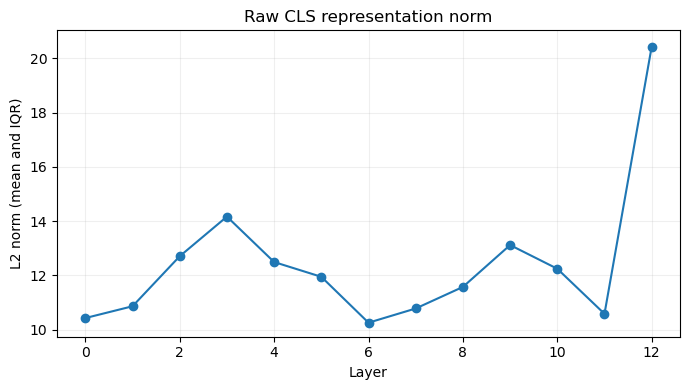

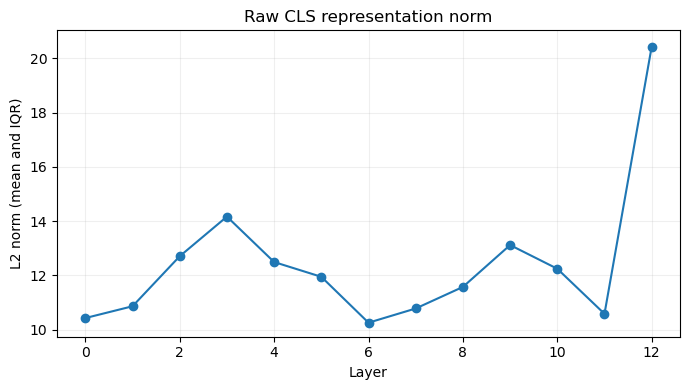

In [5]:
started = time.perf_counter()
representation_artifacts = run_representation_stage(config)
representation_check = validate_representation_artifacts(representation_artifacts.directory)
display(pd.Series({**representation_check, 'elapsed_minutes': (time.perf_counter() - started) / 60}))
display(plot_representation_layer_norms(representation_artifacts.directory))


## 2. Frozen-head descriptive analysis

Layer 0 remains enabled here only. It is excluded from every Ridge and return-factor output.

In [6]:
started = time.perf_counter()
fixed_head_dir = run_fixed_head_analysis_stage(config)
fixed_head_check = validate_fixed_head_analysis_outputs(fixed_head_dir)
display(pd.Series({**fixed_head_check, 'elapsed_minutes': (time.perf_counter() - started) / 60}))

layers             13.000000
transitions        12.000000
elapsed_minutes     0.675458
dtype: float64

## 3. Five static FY0 continuous-label tasks

In [7]:
started = time.perf_counter()
static_target_dir = run_static_target_stage(config)
static_target_check = validate_static_target_outputs(static_target_dir)
display(pd.Series({**static_target_check, 'elapsed_minutes': (time.perf_counter() - started) / 60}))
display(pd.read_csv(static_target_dir / 'static_target_counts.csv'))

rows                                 2766046
tasks                                      5
splits             [test, train, validation]
elapsed_minutes                     1.354563
dtype: object

,task_id,split,rows,reports,weight_sum,label_available_date_max
0,delta_log_dispersion__1m__fixed__fh0,test,18271,18271,16637.104256,2025-08-29
1,delta_log_dispersion__1m__fixed__fh0,train,345683,345683,316979.660884,2023-01-30
2,delta_log_dispersion__1m__fixed__fh0,validation,100950,100950,93677.371390,2025-02-05
3,delta_log_dispersion__1m__market__fh0,test,18092,18092,16520.204059,2025-08-29
4,delta_log_dispersion__1m__market__fh0,train,343630,343630,315666.906151,2023-01-30
5,delta_log_dispersion__1m__market__fh0,validation,100456,100456,93359.305234,2025-02-05
6,delta_log_dispersion__3m__fixed__fh0,test,18674,18674,17599.045723,2025-08-29
7,delta_log_dispersion__3m__fixed__fh0,train,375973,375973,357610.237491,2023-03-29
8,delta_log_dispersion__3m__fixed__fh0,validation,111024,111024,106357.456491,2025-03-31
9,delta_log_dispersion__3m__market__fh0,test,18354,18354,17384.897534,2025-08-29


## 4. Report-level direct five-day return-rank target

In [8]:
started = time.perf_counter()
direct_target_dir = run_static_direct_return_target_stage(config)
direct_target_check = validate_direct_return_target_outputs(direct_target_dir)
display(pd.Series({**direct_target_check, 'elapsed_minutes': (time.perf_counter() - started) / 60}))
display(pd.read_csv(direct_target_dir / 'direct_return_target_audit.csv'))

[info] target_close_spret.h5 percentiles: 9.0900 > 1.00, scaling /100


rows                                                         1050177
reports                                                      1050177
partitions         {'train_tuning': 817065, 'validation': 193221,...
elapsed_minutes                                             0.938369
dtype: object

,stage,reason,count
0,direct_return_target,feature_window_reports,1060258
1,direct_return_target,missing_return_or_nontrading_date,9149
2,direct_return_target,usable_after_purge,1050177
3,direct_return_split,train_tuning,817065
4,direct_return_split,train_boundary_saved_for_final_refit,987
5,direct_return_split,validation,193221
6,direct_return_split,test,38904
7,direct_return_split,purged_cross_boundary_or_missing_target,932


## 5. GPU report-level Ridge, Layer 1–12

The stage first validates the accelerated solver against sklearn, then scans each layer once for all six factor sources. Validation selects alpha; Test never participates in selection.

In [9]:
started = time.perf_counter()
probe_dir = run_static_report_probe_stage(config)
probe_check = validate_static_report_probe_outputs(probe_dir)
display(pd.Series({**probe_check, 'elapsed_minutes': (time.perf_counter() - started) / 60}))
display(pd.read_csv(probe_dir / 'selected_alphas.csv'))

/home/intern_fjq_2026/miniconda3/envs/nlp_fjq/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=9.8372e-09): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


ValueError: array must not contain infs or NaNs

## 6. Historical CSI300 RankIC and layer-factor correlations

CSI300 membership is applied only here, after report weights and predictions are fixed. Validation and Test are reported separately.

In [ ]:
started = time.perf_counter()
evaluation_dir = run_static_csi300_evaluation_stage(config)
evaluation_check = validate_static_csi300_evaluation_outputs(evaluation_dir)
display(pd.Series({**evaluation_check, 'elapsed_minutes': (time.perf_counter() - started) / 60}))
rank_ic_summary = pd.read_csv(evaluation_dir / 'rank_ic_summary.csv')
display(rank_ic_summary.sort_values(['split', 'task_id', 'layer']))
display(plot_static_rank_ic(evaluation_dir, split='validation'))
display(plot_static_rank_ic(evaluation_dir, split='test'))

In [ ]:
for task_id in protocol.task_ids:
    display(plot_static_layer_correlation(evaluation_dir, task_id=task_id, split='test'))
display(plot_static_layer_correlation(evaluation_dir, task_id='direct_return_rank_5d', split='test'))

display(pd.Series({
    'run_directory': str(RUN_DIR),
    'protocol_class': 'conflicting_alternative',
    'pit_label_availability_enforced': False,
    'test_opened_in_same_run': True,
    'modeled_layers': '1-12',
    'status': 'completed',
}, name='run_summary'))